In [5]:
import numpy as np
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('.')  # 添加当前目录到路径

from h2_excited_states import (
    setup_h2_system,
    compute_ground_state,
    compute_1st_excited_state,
    compute_2nd_excited_state,
    compute_all_excited_states,
    plot_convergence,
    plot_energy_levels
)

In [6]:
mol, ha, hi, sampler, e_fci_all, E_fci = setup_h2_system(bond_length=1.74)


Hartree-Fock能量: -0.84390759 Ha
FCI基态能量: -0.96730577 Ha

FCI所有能级:
  E0 (基态) = -0.96730577 Ha
  E1 (第1激发态) = -0.91306114 Ha
  E2 (第2激发态) = -0.42410252 Ha
  E3 (第3激发态) = -0.35953957 Ha

Hilbert空间维度: 4
空间轨道数: 2
电子数: 2


In [16]:
import json
import matplotlib.pyplot as plt
with open('./Data_H2/RBM/ground_state_1.74A.log', 'r') as f:
    data_gs = json.load(f)

with open('./Data_H2/RBM/excited_state_1_1.74A.log', 'r') as f:
    data_ex1 = json.load(f)
    
with open('./Data_H2/RBM/excited_state_2_1.74A.log', 'r') as f:
    data_ex2 = json.load(f)
iter_gs = data_gs["Energy"]["iters"]
iter_ex1 = data_ex1["Energy"]["iters"]
iter_ex2 = data_ex2["Energy"]["iters"]

energy_gs = data_gs["Energy"]["Mean"]['real']
energy_ex1 = data_ex1["Energy"]["Mean"]['real']
energy_ex1[0]=energy_ex1[1]
energy_ex2 = data_ex2["Energy"]["Mean"]['real']
energy_ex2[0]=energy_ex2[1]


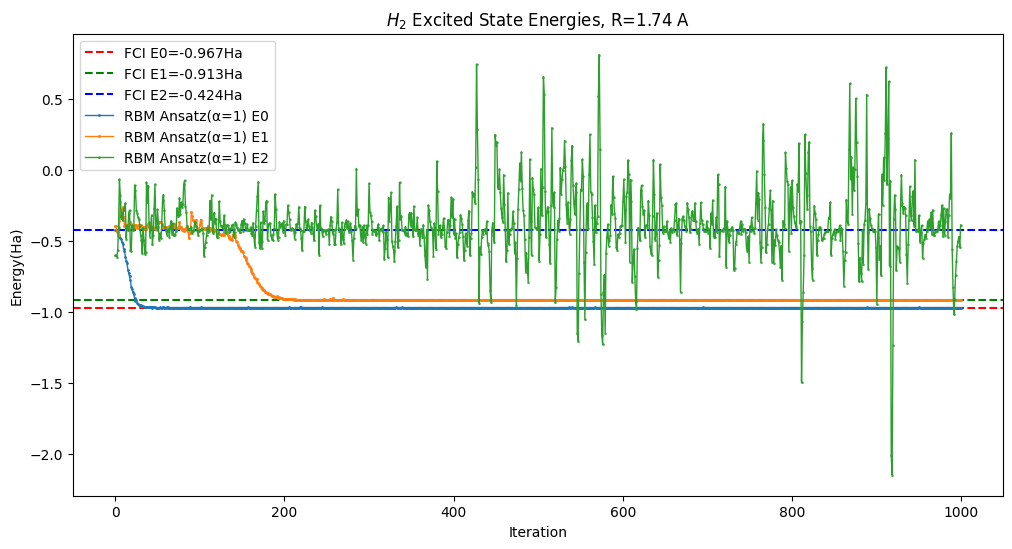

In [17]:
plt.figure(figsize=(12, 6))
plt.xlabel('Iteration')
plt.ylabel('Energy(Ha)')
plt.title('$H_2$ Excited State Energies, R=1.74 A')
plt.axhline(e_fci_all[0], color='r', linestyle='--', label=f'FCI E0={e_fci_all[0]:.3f}Ha')
plt.axhline(e_fci_all[1], color='g', linestyle='--', label=f'FCI E1={e_fci_all[1]:.3f}Ha')
plt.axhline(e_fci_all[2], color='b', linestyle='--', label=f'FCI E2={e_fci_all[2]:.3f}Ha')
plt.plot(iter_gs, energy_gs, 'o-', label='RBM Ansatz(α=1) E0', linewidth=1, markersize=1)
plt.plot(iter_ex1, energy_ex1, 's-', label='RBM Ansatz(α=1) E1', linewidth=1, markersize=1)
plt.plot(iter_ex2, energy_ex2, '^-', label='RBM Ansatz(α=1) E2', linewidth=1, markersize=1)
plt.legend()


In [18]:
with open('./Data_H2/RBM/excited_state_2_1.74A_lamada_5.log', 'r') as f:
    data_ex2_lamada_5 = json.load(f)
iter_ex2_lamada_5 = data_ex2_lamada_5['Energy']['iters']
energy_ex2_lamada_5 = data_ex2_lamada_5['Energy']['Mean']['real']

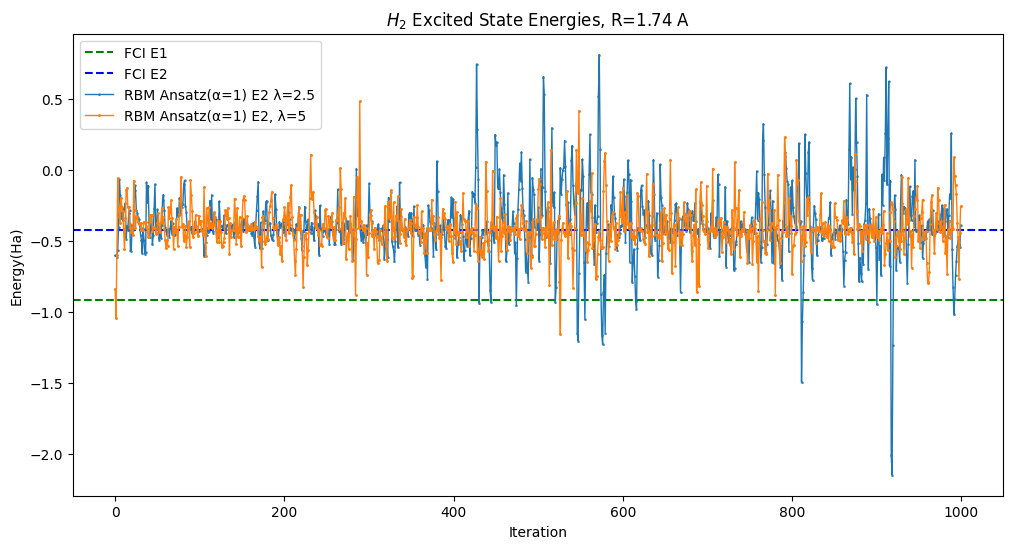

In [19]:
plt.figure(figsize=(12, 6))
plt.xlabel('Iteration')
plt.ylabel('Energy(Ha)')
plt.title('$H_2$ Excited State Energies, R=1.74 A')
#plt.axhline(e_fci_all[0], color='r', linestyle='--', label='FCI E0')
plt.axhline(e_fci_all[1], color='g', linestyle='--', label='FCI E1')
plt.axhline(e_fci_all[2], color='b', linestyle='--', label='FCI E2')
#plt.plot(iter_gs, energy_gs, 'o-', label='RBM Ansatz(α=1) E0', linewidth=1, markersize=1)
# plt.plot(iter_ex1, energy_ex1, 's-', label='RBM Ansatz(α=1) E1', linewidth=1, markersize=1)
plt.plot(iter_ex2, energy_ex2, '^-', label='RBM Ansatz(α=1) E2 λ=2.5', linewidth=1, markersize=1)
plt.plot(iter_ex2_lamada_5, energy_ex2_lamada_5, 'D-', label='RBM Ansatz(α=1) E2, λ=5', linewidth=1, markersize=1)
plt.legend()


In [20]:

with open('./Data_H2/Hybrid/excited_state_2_1.74A.log', 'r') as f:
    data_ex2 = json.load(f)
iter_ex2_hybrid = data_ex2["Energy"]["iters"]
energy_ex2_hybrid = data_ex2["Energy"]["Mean"]['real']


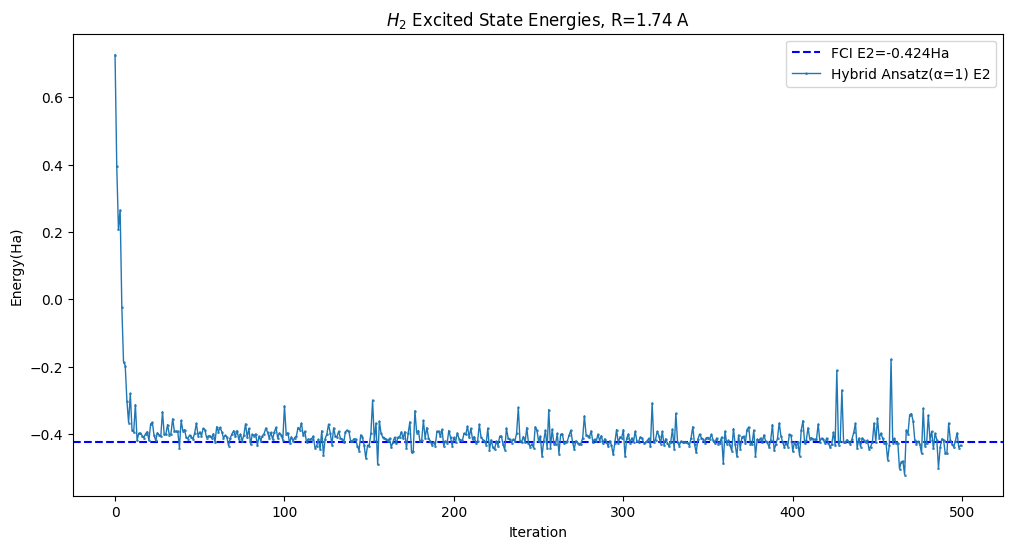

In [21]:
plt.figure(figsize=(12, 6))
plt.xlabel('Iteration')
plt.ylabel('Energy(Ha)')
plt.title('$H_2$ Excited State Energies, R=1.74 A')
plt.axhline(e_fci_all[2], color='b', linestyle='--', label=f'FCI E2={e_fci_all[2]:.3f}Ha')
plt.plot(iter_ex2_hybrid, energy_ex2_hybrid, '^-', label='Hybrid Ansatz(α=1) E2', linewidth=1, markersize=1)
plt.legend()


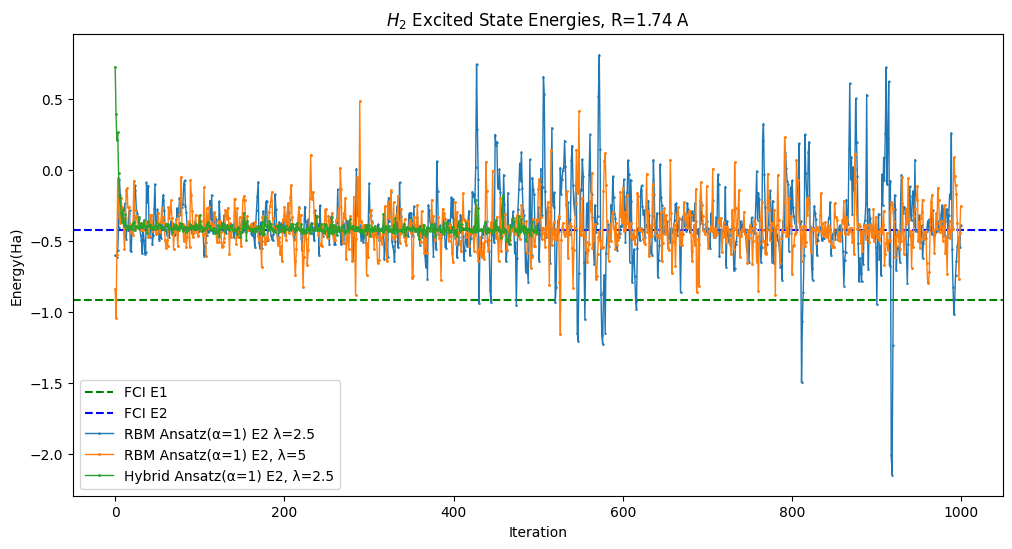

In [23]:
plt.figure(figsize=(12, 6))
plt.xlabel('Iteration')
plt.ylabel('Energy(Ha)')
plt.title('$H_2$ Excited State Energies, R=1.74 A')
#plt.axhline(e_fci_all[0], color='r', linestyle='--', label='FCI E0')
plt.axhline(e_fci_all[1], color='g', linestyle='--', label='FCI E1')
plt.axhline(e_fci_all[2], color='b', linestyle='--', label='FCI E2')
#plt.plot(iter_gs, energy_gs, 'o-', label='RBM Ansatz(α=1) E0', linewidth=1, markersize=1)
# plt.plot(iter_ex1, energy_ex1, 's-', label='RBM Ansatz(α=1) E1', linewidth=1, markersize=1)
plt.plot(iter_ex2, energy_ex2, '^-', label='RBM Ansatz(α=1) E2 λ=2.5', linewidth=1, markersize=1)
plt.plot(iter_ex2_lamada_5, energy_ex2_lamada_5, 'D-', label='RBM Ansatz(α=1) E2, λ=5', linewidth=1, markersize=1)
plt.plot(iter_ex2_hybrid, energy_ex2_hybrid, 'o-', label='Hybrid Ansatz(α=1) E2, λ=2.5', linewidth=1, markersize=1)

plt.legend()
